In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### A) Define the task and prepare the data

The target variable is price per square foot.

Some candidate predictors are X1 through X6, which is what the setup of the dataset seems to convey, but it might be important to note that latitude and longitude do not themselves correlate to closely to price per sq feet unless we have context about these latitude and longitudes as well. For example, if the latitude and longitude was in Seattle, its likely that the price would go up, but if it was in the middle of the ocean it would be an extreme outlier. The only one that makes sense to me is what the house age is. The other data doesn't seem to make sense, like what is "bus station?"

There are no missing values and the data types are integers or floats.

Below are some plots, and also correlation between features and target, however, the only one that seems to have more importance is house age.

In [4]:
df = pd.read_csv("real_estate.csv")
df.columns

Index(['No', 'X1 transaction date', 'X2 house age', 'X3 bus station',
       'X4 number of stores', 'X5 latitude', 'X6 longitude',
       'Y price sq feet'],
      dtype='str')

In [5]:
df.head()

,No,X1 transaction date,X2 house age,X3 bus station,X4 number of stores,X5 latitude,X6 longitude,Y price sq feet
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,92.1
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,82.4
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,93.6
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,97.3
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,99.9


In [6]:
int(df["X1 transaction date"].isna().sum()) + int(df["X2 house age"].isna().sum()) + int(df["X3 bus station"].isna().sum()) + int(df["X4 number of stores"].isna().sum()) + int(df["X5 latitude"].isna().sum()) + int(df["X6 longitude"].isna().sum())

0

In [8]:
df.corr()

,No,X1 transaction date,X2 house age,X3 bus station,X4 number of stores,X5 latitude,X6 longitude,Y price sq feet
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,0.008751,0.016236,0.043242
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.070071,-0.046939,-0.035711
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,-0.058646,-0.045480,-0.862268
X3 bus station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.020164,0.027354,0.009766
X4 number of stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.022794,-0.064176,-0.058295
X5 latitude,0.008751,0.070071,-0.058646,-0.020164,0.022794,1.000000,-0.002481,0.033060
X6 longitude,0.016236,-0.046939,-0.045480,0.027354,-0.064176,-0.002481,1.000000,-0.011587
Y price sq feet,0.043242,-0.035711,-0.862268,0.009766,-0.058295,0.033060,-0.011587,1.000000


In [7]:
df.describe()

,No,X1 transaction date,X2 house age,X3 bus station,X4 number of stores,X5 latitude,X6 longitude,Y price sq feet
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.908709,121.239786,97.754106
std,119.655756,0.281967,11.392485,1262.109595,2.945562,1.227223,5.973058,12.850456
min,1.000000,2012.667000,0.000000,23.382840,0.000000,0.000000,0.000000,65.300000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.962990,121.527600,89.025000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,99.350000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,106.675000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,127.000000


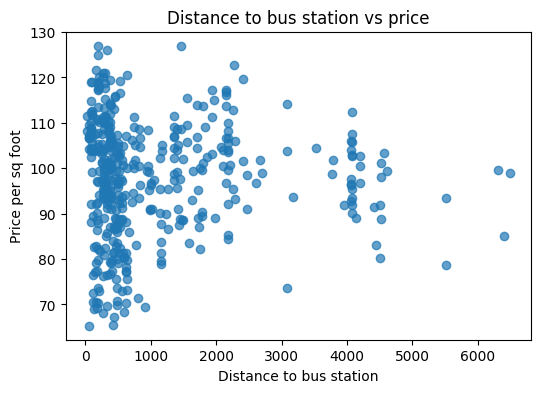

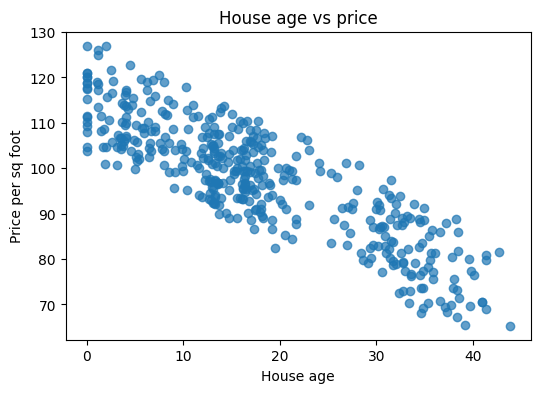

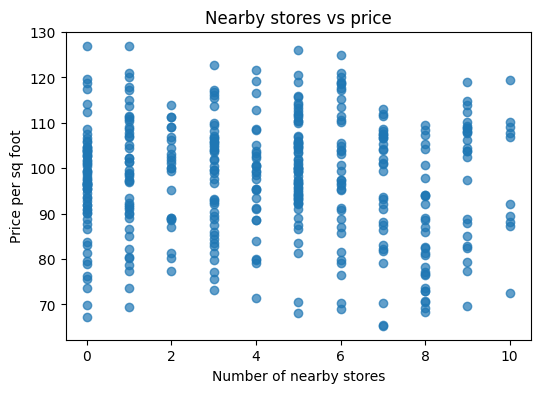

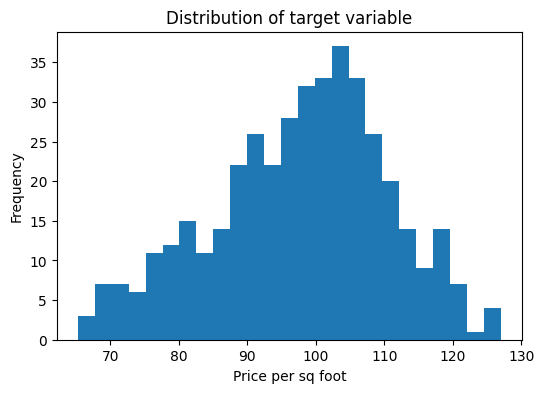

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(df["X3 bus station"], df["Y price sq feet"], alpha=0.7)
plt.xlabel("Distance to bus station")
plt.ylabel("Price per sq foot")
plt.title("Distance to bus station vs price")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["X2 house age"], df["Y price sq feet"], alpha=0.7)
plt.xlabel("House age")
plt.ylabel("Price per sq foot")
plt.title("House age vs price")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df["X4 number of stores"], df["Y price sq feet"], alpha=0.7)
plt.xlabel("Number of nearby stores")
plt.ylabel("Price per sq foot")
plt.title("Nearby stores vs price")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["Y price sq feet"], bins=25)
plt.xlabel("Price per sq foot")
plt.ylabel("Frequency")
plt.title("Distribution of target variable")
plt.show()

### Building candidate models

Below I interpret results of r^2, MAE, MSE, RMSE, evalaute on validation set.

one fixed train/validation/test split for the whole project.

- 60% training
- 20% validation
- 20% test

The validation set is used to compare candidate models. The test set is held out until the final evaluation.

In [22]:
target = "Y price sq feet"

features = [
    "X1 transaction date",
    "X2 house age",
    "X3 bus station",
    "X4 number of stores",
    "X5 latitude",
    "X6 longitude"
]

X_train, X_temp, y_train, y_temp = train_test_split(
    df[features], df[target], test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (248, 6) (248,)
Validation set: (83, 6) (83,)
Test set: (83, 6) (83,)


In [23]:
def evaluate_model(model, X_train, y_train, X_eval, y_eval, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_eval)

    mse = mean_squared_error(y_eval, y_pred)
    rmse = np.sqrt(mse)

    return {
        "Model": model_name,
        "R²": r2_score(y_eval, y_pred),
        "MAE": mean_absolute_error(y_eval, y_pred),
        "MSE": mse,
        "RMSE": rmse
    }

### Model 1: Single-feature linear regression

For the single-feature model, I use X3 bus station, which I think represents distance to the nearest public transportation station. This is a reasonable single predictor because location and transportation access are likely related to real estate price.

This model uses only distance to the bus station. It is simple and easy to interpret, but it leaves out many other factors that affect price. If its validation error is high or its $R^2$ is low, that suggests just one featrue is not enough to explain price differences well

In [25]:
single_feature = "X3 bus station"

single_feature_model = LinearRegression()

single_feature_results = evaluate_model(
    single_feature_model,
    X_train[[single_feature]],
    y_train,
    X_val[[single_feature]],
    y_val,
    "Single-feature linear regression"
)

single_feature_results

{'Model': 'Single-feature linear regression',
 'R²': -0.05152768761072535,
 'MAE': 11.55811219390609,
 'MSE': 199.8807448401466,
 'RMSE': np.float64(14.137918688411904)}

### Model 2: Multiple linear regression

The multiple linear regression model uses all six candidate predictors. This tests whether adding more information improves prediction compared with the single-feature model. This usually performs better than the single-feature model because it uses more information, including house age, transaction date, nearby stores, latitude, and longitude. However, it is still restricted to linear relationships.

In [26]:
multiple_linear_model = LinearRegression()

multiple_linear_results = evaluate_model(
    multiple_linear_model,
    X_train,
    y_train,
    X_val,
    y_val,
    "Multiple linear regression"
)

multiple_linear_results

{'Model': 'Multiple linear regression',
 'R²': 0.7563078906479986,
 'MAE': 5.659722465656735,
 'MSE': 46.32247053771983,
 'RMSE': np.float64(6.806061308695348)}

### Model 3: Polynomial regression

The polynomial regression model uses degree-2 polynomial features. Because polynomial terms can have very different scales, I use a pipeline with StandardScaler, PolynomialFeatures, and LinearRegression

In [18]:
polynomial_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

polynomial_results = evaluate_model(
    polynomial_model,
    X_train,
    y_train,
    X_val,
    y_val,
    "Polynomial regression degree 2"
)

polynomial_results

{'Model': 'Polynomial regression degree 2',
 'R²': 0.7419478107549273,
 'MAE': 5.75017718129262,
 'MSE': 49.052121405509155,
 'RMSE': np.float64(7.00372196803308)}

## Part C: Select the best model

The table below compares the validation performance of all candidate models.

The best one is multiple linear regression.

In [19]:
validation_results = pd.DataFrame([
    single_feature_results,
    multiple_linear_results,
    polynomial_results
])

validation_results = validation_results.sort_values(by="RMSE").reset_index(drop=True)
validation_results

,Model,R²,MAE,MSE,RMSE
0,Multiple linear regression,0.756308,5.659722,46.322471,6.806061
1,Polynomial regression degree 2,0.741948,5.750177,49.052121,7.003722
2,Single-feature linear regression,-0.051528,11.558112,199.880745,14.137919


### Part C discussion

The multiple linear regression model is the best model because it has the best validation performance overall, especially based on RMSE and MSE.

Adding more features increased performance compared with the single-feature model, which was too limited because price depends on more than one variable. Polynomial regression did not improve validation performance in this split. Although it can model more complex relationships, it may have added unnecessary complexity, or had a fitting problem with the data?

The metrics mostly agreed: the model with the lowest RMSE also had the lowest MSE and strong MAE/R^2 performance. Since RMSE penalizes larger errors more heavily, it is useful here because very large price prediction errors are especially undesirable.

## Part D: Final test evaluation

Now that the best model has been selected using validation results, I evaluate it once on the test set.


In [27]:
# Refit the selected model on the training set and evaluate once on the test set, nased on validation results, 
#the selected model is multiple linear regression.

selected_model = LinearRegression()

selected_model.fit(X_train, y_train)
test_predictions = selected_model.predict(X_test)

test_mse = mean_squared_error(y_test, test_predictions)

test_results = {
    "Model": "Selected model: multiple linear regression",
    "R²": r2_score(y_test, test_predictions),
    "MAE": mean_absolute_error(y_test, test_predictions),
    "MSE": test_mse,
    "RMSE": np.sqrt(test_mse)
}

test_results

{'Model': 'Selected model: multiple linear regression',
 'R²': 0.7474873759568069,
 'MAE': 5.217877159457882,
 'MSE': 37.74688461011282,
 'RMSE': np.float64(6.143849331657867)}

In [21]:
# Compare validation and test performance for the selected model
selected_validation_results = multiple_linear_results.copy()
selected_validation_results["Split"] = "Validation"

selected_test_results = test_results.copy()
selected_test_results["Split"] = "Test"

pd.DataFrame([selected_validation_results, selected_test_results])[
    ["Split", "Model", "R²", "MAE", "MSE", "RMSE"]
]

,Split,Model,R²,MAE,MSE,RMSE
0,Validation,Multiple linear regression,0.756308,5.659722,46.322471,6.806061
1,Test,Selected model: multiple linear regression,0.747487,5.217877,37.746885,6.143849


### discourse

The test performance is reasonably close to the validation performance. This suggests that the selected model generalized fairly well and that the validation result was not just a fluke.

I would trust this model for a rough estimate or exploratory analysis, but I would not rely on it alone for a high-stakes real estate decision. Real estate prices depend on many additional factors not included here, such as property condition, exact neighborhood quality, market timing, renovations, school districts, and broader economic conditions.

## Part E: Reflection and next steps

Comparing the models showed me that adding relevant predictors can improve performance a lot, but adding complexity does not automatically make a model better. The single-feature model was too simple because real estate prices depend on many factors, and not necesarrily the ones given in this dataset. The multiple linear regression model performed best on validation data, while the polynomial model did not improve enough to justify the extra complexity. I found RMSE most useful because it is in the same units as the target variable and penalizes large prediction errors more strongly than MAE. One limitation of the final model is that it only uses a small set of numeric variables and may miss important qualitative information about each property. A realistic next step would be to try other more complex models, or like in class today, compare against tree-based models.